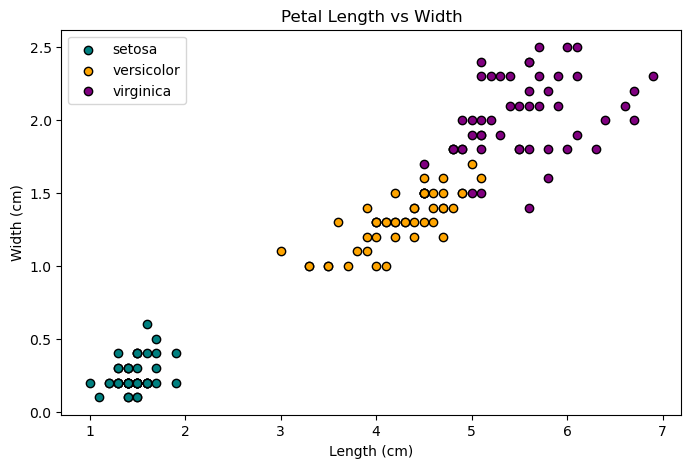

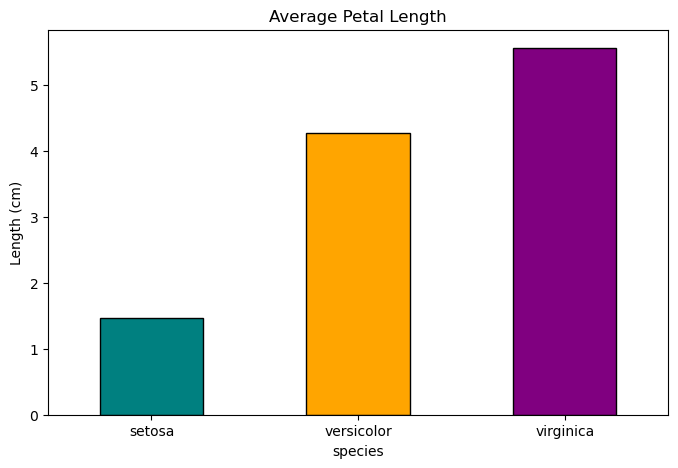

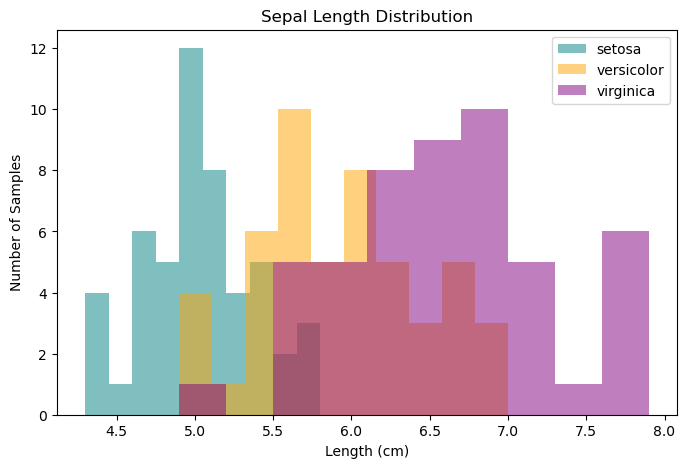

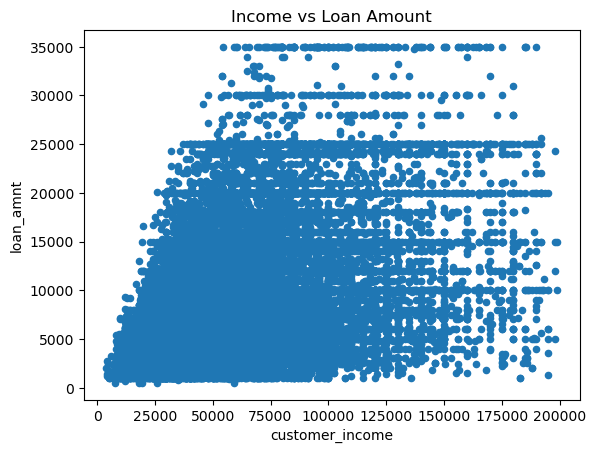

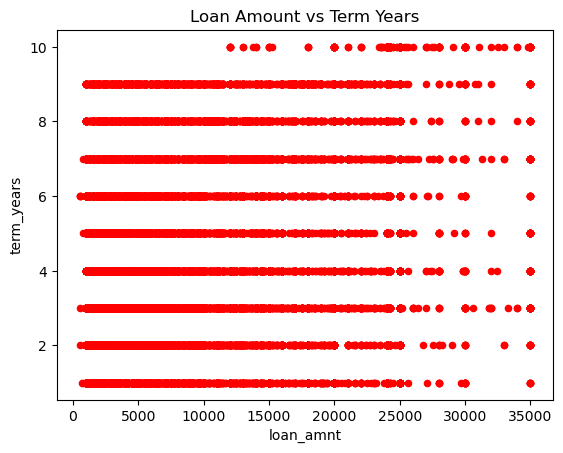

[Text(0.5, 1.0, 'Home Ownership'),
 Text(0.5, 0, 'Type of Ownership'),
 Text(0, 0.5, 'Number of People with Ownership')]

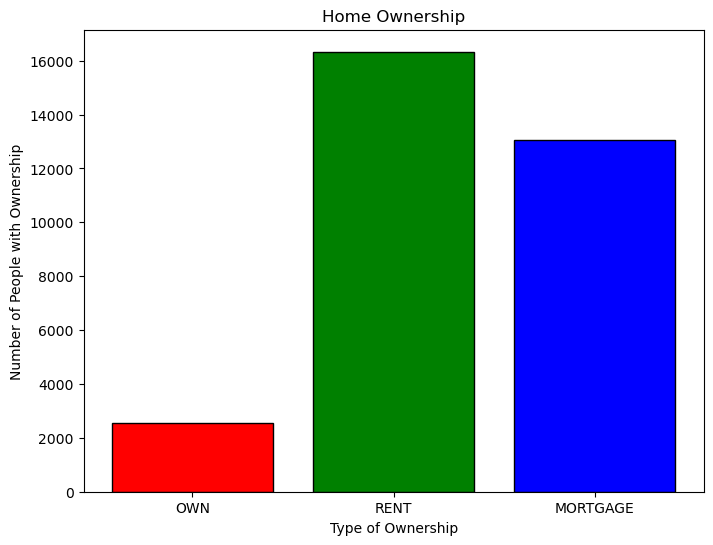

In [41]:
#imports
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris

#=========================================================================================================================
#Part 1


#load iris data set
iris = load_iris()
df = pd.DataFrame(iris.data, columns=['sepal_l', 'sepal_w', 'petal_l', 'petal_w'])#put it in a data frame
df['species'] = [iris.target_names[i] for i in iris.target]#maps numeric data to species name
colors = {'setosa': 'teal', 'versicolor': 'orange', 'virginica': 'purple'}

#----------1: Scatter plot to display the different Petal Length and widths between flower species---------|

plt.figure(figsize=(8, 5))
#loops through to plot everything with different colors
for species, color in colors.items():
    subset = df[df['species'] == species]
    plt.scatter(subset['petal_l'], subset['petal_w'], label=species, c=color, edgecolors='k')

#customize display
plt.title('Petal Length vs Width')
plt.xlabel('Length (cm)')
plt.ylabel('Width (cm)')
plt.legend()
plt.show()

#------2: This shows the difference between the average petal lenght betwween each of the different species------|

averages = df.groupby('species')['petal_l'].mean()
plt.figure(figsize=(8, 5))
averages.plot(kind='bar', color=['teal', 'orange', 'purple'], edgecolor='black')
#customize display
plt.title('Average Petal Length')
plt.ylabel('Length (cm)')
plt.xticks(rotation=0) # Keeps the species names flat
plt.show()

#-----3 This groups the sepal lenghts and puts them in categories. It makes seing the distribution much easier-------|

plt.figure(figsize=(8, 5))
#plot each histogram and overlay to see the difference
for species, color in colors.items():
    subset = df[df['species'] == species]
    plt.hist(subset['sepal_l'], bins=10, alpha=0.5, label=species, color=color)

#customize display
plt.title('Sepal Length Distribution')
plt.xlabel('Length (cm)')
plt.ylabel('Number of Samples')
plt.legend()
plt.show()

#=================================================================================================================================
#Part 2

# Load the CSV file
df_loans = pd.read_csv('LoanDataset - LoansDatasest.csv')

#----------1. This visualization helps us see the trend between loan amount and customer income-----------|

#this gets rid of the commas and signs in the loan amount
df_loans['loan_amnt'] = (
    df_loans['loan_amnt']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('£', '', regex=False)
)

#this converts both columns used to integers
df_loans['loan_amnt'] = pd.to_numeric(df_loans['loan_amnt'], errors='coerce')
df_loans['customer_income'] = pd.to_numeric(df_loans['customer_income'], errors='coerce')

#this gets rid of outliers
df_loans = df_loans[df_loans['loan_amnt'] < 100000]
df_loans = df_loans[df_loans['customer_income'] < 200000]

#this drops any empty values
df_loans = df_loans.dropna(subset=['loan_amnt'])
df_loans = df_loans.dropna(subset=['customer_income'])

#plot and display
df_loans.plot.scatter(x='customer_income', y='loan_amnt', title='Income vs Loan Amount')
plt.show()

#---------------------2. This helps us see the trend of year terms vs loan amount-------------------|

#this converts the column into integers
df_loans['term_years'] = pd.to_numeric(df_loans['term_years'], errors='coerce')

#this drops any empty values
df_loans= df_loans.dropna(subset=['term_years'])

#plot and display
df_loans.plot.scatter(x='loan_amnt',y='term_years', color='red', title='Loan Amount vs Term Years')
plt.show()

#------------------------3. This helps us see the most common type of ownership easily----------------|

#puts ownership types into into a list 
ownership = []
for s in df_loans['home_ownership']:
    if s == 'OWN': 
        ownership.append('OWN')
    elif s == 'RENT': 
        ownership.append('RENT')
    elif s == 'MORTGAGE': 
        ownership.append('MORTGAGE')

#ownership labels and counting each one
labels = ['OWN', 'RENT', 'MORTGAGE']
counts = [ownership.count(g) for g in labels]

#create a figure and plot bargraph
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(labels, counts, color=['red','green','blue'], edgecolor='black')
ax.set(title="Home Ownership", xlabel="Type of Ownership", ylabel="Number of People with Ownership")